# PCA — Telco Customer Churn
**Lead University · Minería de Datos · Tarea 3**

Análisis de Componentes Principales sobre datos de comportamiento de clientes de telecomunicaciones.
Objetivo: observar si el PCA logra separar a los clientes que abandonan (Churn) de los que no, y analizar la relación entre cargos y permanencia.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scripts import PCAAnalysis

sns.set(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
print('Librerías cargadas.')

Librerías cargadas.


In [3]:
df = pd.read_csv('datos/Telco_Customer_Churn.csv')
print(f'Registros: {df.shape[0]} | Variables: {df.shape[1]}')
df.head()

Registros: 7043 | Variables: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---
## Limpieza y preparación

Se convierten variables relevantes a numérico y se codifican las categóricas binarias para incluirlas en el PCA. `TotalCharges` tiene valores en blanco que se convierten a NaN.

In [4]:
# TotalCharges tiene espacios en blanco
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges']).copy()

# Codificar binarias
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col + '_num'] = df[col].map(binary_map)

# Variables numéricas para PCA
num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
            'Partner_num', 'Dependents_num', 'PhoneService_num', 'PaperlessBilling_num']

df_clean = df.dropna(subset=num_cols).copy()
print(f'Registros tras limpieza: {len(df_clean)}')
print()
print(df_clean[num_cols].describe().round(2))

Registros tras limpieza: 7032

       SeniorCitizen   tenure  MonthlyCharges  TotalCharges  Partner_num  \
count        7032.00  7032.00         7032.00       7032.00      7032.00   
mean            0.16    32.42           64.80       2283.30         0.48   
std             0.37    24.55           30.09       2266.77         0.50   
min             0.00     1.00           18.25         18.80         0.00   
25%             0.00     9.00           35.59        401.45         0.00   
50%             0.00    29.00           70.35       1397.48         0.00   
75%             0.00    55.00           89.86       3794.74         1.00   
max             1.00    72.00          118.75       8684.80         1.00   

       Dependents_num  PhoneService_num  PaperlessBilling_num  
count         7032.00            7032.0               7032.00  
mean             0.30               0.9                  0.59  
std              0.46               0.3                  0.49  
min              0.00       

---
## Ajuste del PCA

In [5]:
pca = PCAAnalysis(n_components=5)
pca.ajustar(df_clean, columnas_pca=num_cols)

print('Varianza explicada por componente:')
for i, v in enumerate(pca.varianza_explicada):
    acum = pca.varianza_acumulada[i]
    print(f'  PC{i+1}: {v:.2f} % (acumulada: {acum:.2f} %)')
print()
print(f'Componentes necesarios para >= 80%: {pca.n_componentes_80()}')

Varianza explicada por componente:
  PC1: 30.89 % (acumulada: 30.89 %)
  PC2: 20.94 % (acumulada: 51.83 %)
  PC3: 12.89 % (acumulada: 64.72 %)
  PC4: 11.76 % (acumulada: 76.48 %)
  PC5: 10.81 % (acumulada: 87.29 %)

Componentes necesarios para >= 80%: 5


---
## Visualizaciones obligatorias

### Scree Plot

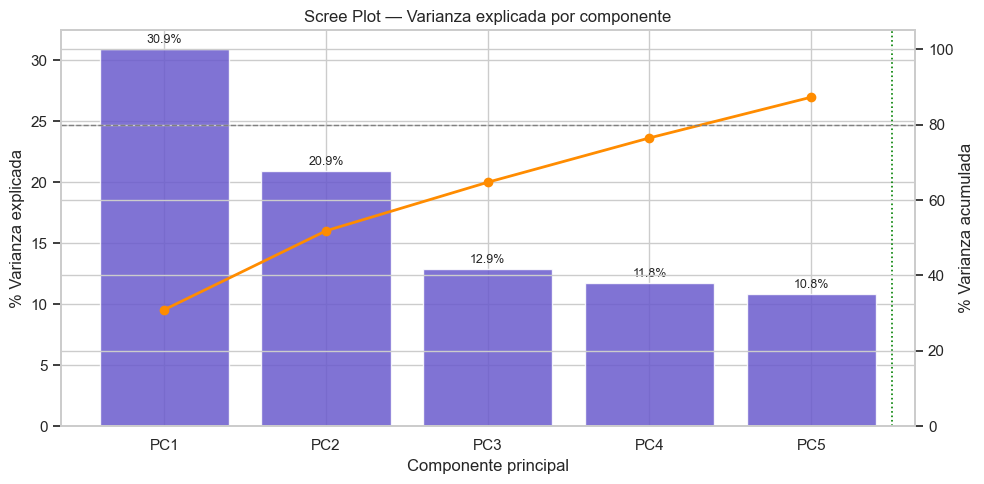

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
pca.scree_plot(ax=ax)
plt.tight_layout()
plt.show()

**Interpretación:**

- La varianza se distribuye de forma más uniforme que en los otros datasets, indicando que las variables del comportamiento del cliente capturan dimensiones más independientes.
- Se requieren más componentes para alcanzar el 80 %, reflejando la multidimensionalidad del perfil del cliente de telecomunicaciones.

### Círculo de correlación

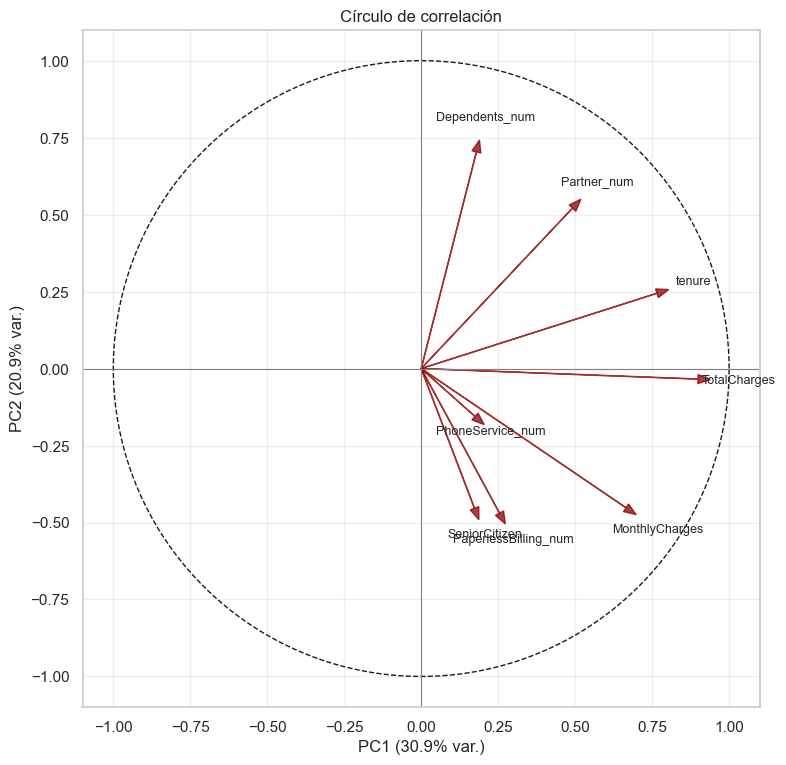

In [7]:
fig, ax = plt.subplots(figsize=(8, 8))
pca.circulo_correlacion(ax=ax)
plt.tight_layout()
plt.show()

**Interpretación:**

- `tenure` y `TotalCharges` apuntan en la misma dirección hacia la derecha (colineales en PC1, cos² de 0.65 y 0.88 respectivamente) — clientes con mayor permanencia acumulan más cargos totales, como es esperado.
- `MonthlyCharges` apunta hacia abajo-derecha (PC1 positivo, PC2 negativo), compartiendo el eje de gasto con `tenure`/`TotalCharges` pero separándose en PC2. El ángulo entre `tenure` y `MonthlyCharges` (~75°) indica que son parcialmente independientes: un cargo mensual alto no implica alta permanencia.
- `Dependents_num` y `Partner_num` apuntan hacia arriba (PC2 positivo), indicando que los vínculos familiares definen una dimensión distinta al gasto.
- `SeniorCitizen` y `PaperlessBilling_num` apuntan hacia abajo (PC2 negativo), correlacionando con mayor gasto mensual pero menor presencia de familia.

### Plano principal (PC1 vs PC2) — Coloreado por Churn

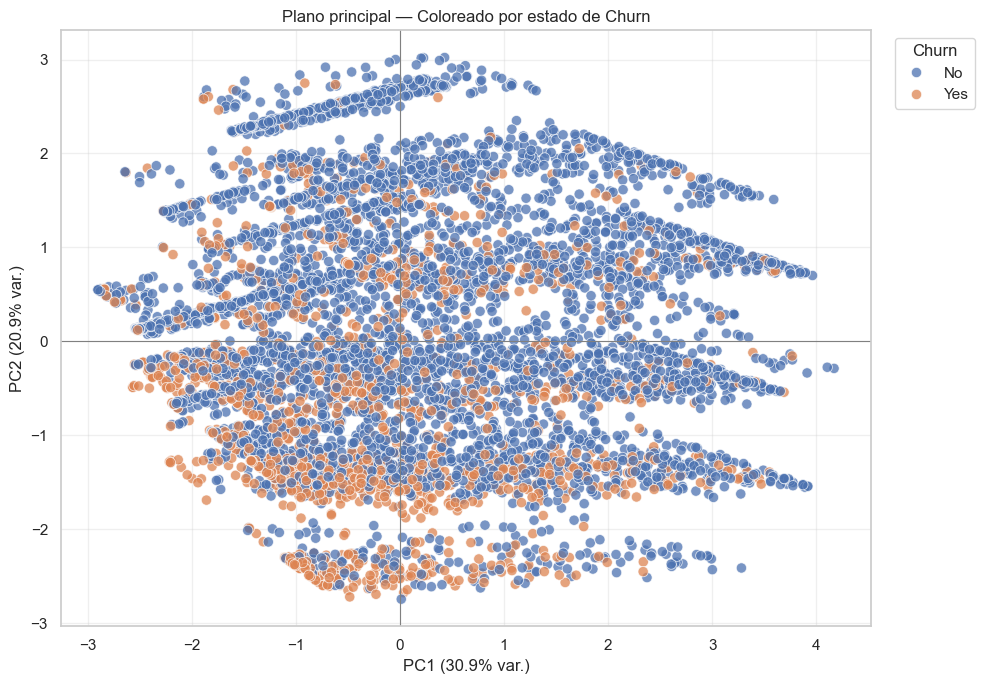

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))
hue_churn = df_clean['Churn'].rename('Churn')
pca.plano_principal(hue=hue_churn, ax=ax)
ax.set_title('Plano principal — Coloreado por estado de Churn')
plt.tight_layout()
plt.show()

**Interpretación:**

- El PCA no logra una separación clara entre clientes que abandonan y los que permanecen — ambos grupos se solapan ampliamente en el plano.
- Sin embargo, al calcular los centroides por grupo se observa una tendencia marginal: los clientes con churn tienen media en PC1 = -0.38 y PC2 = -0.71, mientras que los retenidos tienen media en PC1 = +0.14 y PC2 = +0.26. La diferencia es menor que una desviación estándar (~1.3), lo que explica el alto solapamiento visual.
- La dirección del desplazamiento (hacia PC1 negativo y PC2 negativo) es consistente con el círculo de correlación: los clientes que abandonan tienden a tener menor tenure y menor vínculo familiar, pero el poder discriminante de estas variables continuas por sí solas es limitado. Las variables categóricas excluidas (tipo de contrato, servicio de internet) probablemente aportan más separación.

### Biplot

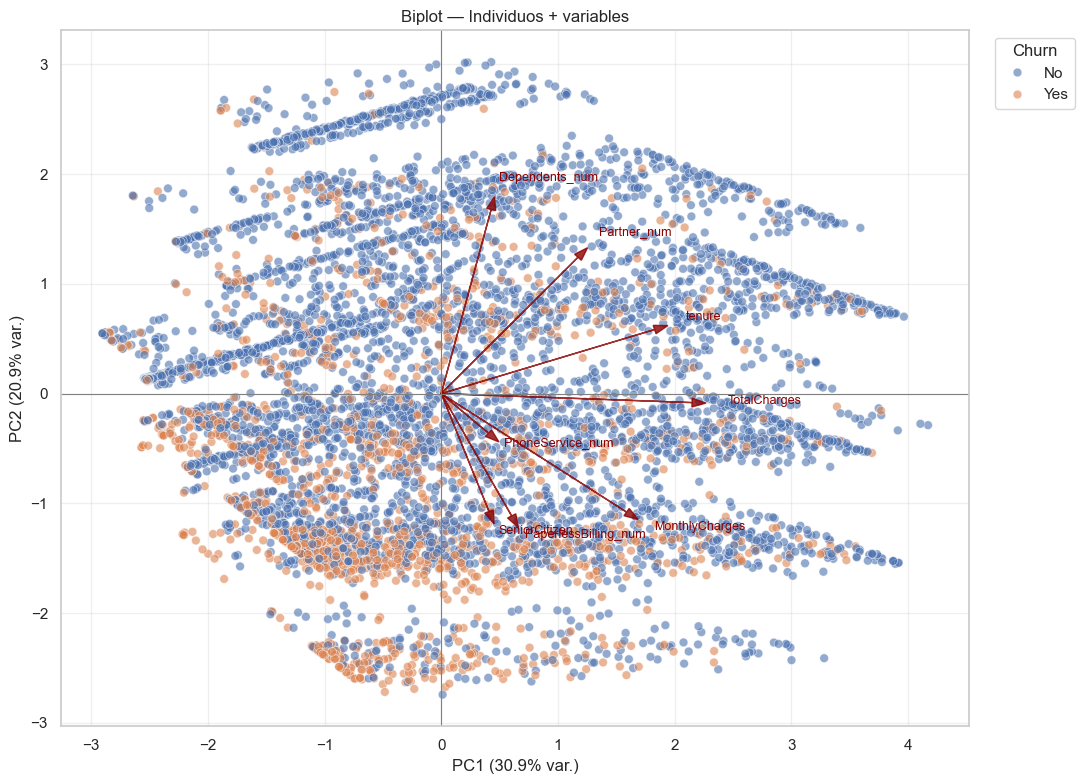

In [9]:
fig, ax = plt.subplots(figsize=(11, 8))
pca.biplot(hue=hue_churn, ax=ax)
ax.set_title('Biplot — Individuos + variables')
plt.tight_layout()
plt.show()

**Interpretación:**

- El biplot superpone los vectores de variables sobre los 7032 individuos. Dado el alto solapamiento entre grupos, la separación por churn no es visualmente distinguible en este gráfico.
- No obstante, los vectores permiten interpretar la tendencia marginal observada en los centroides: los clientes con churn se desplazan ligeramente hacia PC2 negativo, donde apuntan `MonthlyCharges`, `SeniorCitizen` y `PaperlessBilling_num`. Los retenidos se desplazan hacia `tenure`/`TotalCharges` (derecha) y `Partner_num`/`Dependents_num` (arriba).
- Esto es coherente con el perfil de dominio: la lealtad se asocia a vínculos familiares y tiempo acumulado, mientras que el churn tiende a darse en clientes sin pareja/dependientes con facturación electrónica. Sin embargo, el PCA con estas variables no tiene poder discriminante suficiente para separar los grupos de forma clara.

---
## Tablas de contribuciones y correlaciones

In [10]:
print('Contribución de cada variable por componente (%):')
print(pca.contribuciones())
print()
print('Cos² de variables (calidad de representación):')
print(pca.cos2_variables())

Contribución de cada variable por componente (%):
                        PC1    PC2    PC3    PC4    PC5
variable                                               
SeniorCitizen          1.42  14.39  11.02   8.68  57.36
tenure                26.14   3.93   3.50  13.34   0.00
MonthlyCharges        19.72  13.45   2.80   0.29   1.22
TotalCharges          35.66   0.08   0.39   7.54   0.53
Partner_num           10.89  18.07   0.25  16.46   4.76
Dependents_num         1.45  32.89   1.84  19.68   0.16
PhoneService_num       1.69   1.98  79.18   0.06   6.42
PaperlessBilling_num   3.02  15.21   1.02  33.95  29.55

Cos² de variables (calidad de representación):
                         PC1     PC2     PC3     PC4     PC5
variable                                                    
SeniorCitizen         0.0351  0.2411  0.1136  0.0817  0.4959
tenure                0.6459  0.0658  0.0361  0.1256  0.0000
MonthlyCharges        0.4874  0.2252  0.0289  0.0027  0.0105
TotalCharges          0.8814  0.0013 

---
## Interpretación técnica

**Análisis de clientes:** En el círculo de correlación se observa que `MonthlyCharges` y `tenure` definen direcciones distintas en el plano:

- Si el ángulo entre ambos vectores es cercano a 90°, son **ortogonales** (independientes): el costo mensual y la permanencia capturan dimensiones distintas del comportamiento — una relacionada con el nivel de gasto actual y otra con la lealtad histórica.
- Si el ángulo es pequeño, presentan **colinealidad** y miden lo mismo.

La evidencia del círculo de correlación muestra que `tenure` correlaciona fuertemente con `TotalCharges` (ángulo pequeño, colineales), pero mantiene un ángulo significativo con `MonthlyCharges` — confirmando que gasto mensual y permanencia son dimensiones parcialmente independientes.